## 라이브러리 설치 및 임포트

In [1]:
!pip install nptdms
import gdown
import zipfile
import os
from nptdms import TdmsFile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import ipywidgets as widgets
from IPython.display import display

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.5/181.5 kB 3.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for nptdms: filename=nptdms-1.10.0-py3-none-any.whl size=108456 sha256=c892ffc4e47570ed463f0fc851207e803472199d6bd386358fc930e97c1311e6
  Stored in directory: /root/.cache/pip/wheels/1b/4b/17/21e8b03b37ea51ce7ec9f5570cdf0decca93f537d61c06880f
Successfully built nptdms


# 구글 드라이브에 저장된 파일 링크로 데이터 불러오기

In [2]:
# https://drive.google.com/file/d/1qz0b66_MWXo1_psEhBpeMesSSXTmZdlE/view?usp=sharing

# 공유 링크에서 파일 ID 추출
file_id = '1qz0b66_MWXo1_psEhBpeMesSSXTmZdlE'

# 저장할 zip 파일 이름
zip_path = 'data.zip'
extract_dir = 'data'

# 다운로드
gdown.download(f'https://drive.google.com/uc?id={file_id}', zip_path, quiet=False)

# 압축 해제
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"압축 해제 완료: {extract_dir}/")

Downloading...
From (original): https://drive.google.com/uc?id=1qz0b66_MWXo1_psEhBpeMesSSXTmZdlE
From (redirected): https://drive.google.com/uc?id=1qz0b66_MWXo1_psEhBpeMesSSXTmZdlE&confirm=t&uuid=cf67d403-62ec-45a9-9926-72136ce4bc06
To: /content/data.zip
100%|██████████| 4.19G/4.19G [00:56<00:00, 74.6MB/s]


압축 해제 완료: data/


# 아래 코드 실행하기 위해 필요한 함수

In [22]:
# 데이터 처리
def load_tdms_file(file_path):
    tdms_file = TdmsFile.read(file_path)

    # group_name_vibration: {CH1, CH2, CH3, CH4} 데이터, group_name_operation: {Torque[Nm], TC SP Front[℃], TC SP Rear[℃]} 데이터
    group_name_vibration = tdms_file.groups()[0].name
    group_name_operation = tdms_file.groups()[1].name

    vib_channels = tdms_file[group_name_vibration].channels()
    vib_data = {ch.name: ch.data for ch in vib_channels}

    operation_channels = tdms_file[group_name_operation].channels()
    operation_data = {ch.name: ch.data for ch in operation_channels}

    return vib_data , operation_data


# 데이터 프레임 형태로 변환
def create_time_indexed_dataframe(vib_data, operation_data, fs=25600):
    """
    vib_data: {'CH1': np.array, 'CH2': np.array, ...}
    operation_data: {'Torque[Nm]': np.array([val]), ...}
    fs: sampling frequency in Hz (default: 25.6 kHz)
    """

    # 데이터 길이 (CH1 기준으로 동일하다고 가정)
    N = len(vib_data["CH1"])

    # 시간 인덱스 생성
    time_index = np.arange(N) / fs

    # 진동 데이터프레임 구성
    df = pd.DataFrame(vib_data, index=time_index)
    df.index.name = "Time (s)"

    # 상태값 broadcast (모든 row에 동일하게 삽입)
    for key, val in operation_data.items():
        clean_key = key.strip()  # 공백 제거 (예: '   TC SP Front[℃]')
        df[clean_key] = val[0]

    return df



# raw 데이터 시각화
def plot_vibration_channels(df, channels=["CH1", "CH2", "CH3", "CH4"]):
    """
    시간 인덱스를 가진 df에서 지정된 채널들을 시간에 따라 시각화
    """
    plt.figure(figsize=(14, 8))

    for i, ch in enumerate(channels, 1):
        plt.subplot(len(channels), 1, i)
        plt.plot(df.index, df[ch], linewidth=0.5)
        plt.title(f"{ch} vs Time", fontsize=12)
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.grid(True)

    plt.tight_layout()
    plt.show()


# window 사이즈 설정 후 rms 처리하고 시각화
def plot_rms_over_time(df, channels=["CH1", "CH2", "CH3", "CH4"], window_size=1000, fs=25600):
    """
    지정된 채널들의 RMS를 window 단위로 계산 후 시각화
    """
    plt.figure(figsize=(14, 8))

    for i, ch in enumerate(channels, 1):
        signal = df[ch].values
        n = len(signal)

        # RMS 계산
        rms_values = [
            np.sqrt(np.mean(signal[j:j+window_size]**2))
            for j in range(0, n - window_size + 1, window_size)
        ]

        # 시간 인덱스 생성 (윈도우 중심)
        time_index = np.arange(len(rms_values)) * (window_size / fs)

        # 플롯
        plt.subplot(len(channels), 1, i)
        plt.plot(time_index, rms_values, linewidth=0.8)
        plt.title(f"RMS of {ch} (window={window_size})", fontsize=12)
        plt.xlabel("Time (s)")
        plt.ylabel("RMS Amplitude")
        plt.grid(True)

    plt.tight_layout()
    plt.show()



# 파일 선택 콤보박스로 하게 해주는 함수
def select_tdms_file():
    global data_dir  # 전역으로 저장

    root_folder = "data/Train Set"

    # 폴더 리스트 가져오기
    train_folders = sorted([
        f for f in os.listdir(root_folder)
        if os.path.isdir(os.path.join(root_folder, f))
    ])

    # 폴더 선택 드롭다운
    folder_dropdown = widgets.Dropdown(
        options=train_folders,
        description="폴더 선택:",
        layout=widgets.Layout(width='50%')
    )

    # 파일 선택 드롭다운
    file_dropdown = widgets.Dropdown(
        options=[],
        description="파일 선택:",
        layout=widgets.Layout(width='60%')
    )

    display(folder_dropdown)
    display(file_dropdown)

    # 폴더 선택 시 파일 목록 갱신
    def update_file_list(change):
        selected_folder = change.new
        full_path = os.path.join(root_folder, selected_folder)
        tdms_files = sorted([
            f for f in os.listdir(full_path) if f.endswith(".tdms")
        ])
        file_dropdown.options = tdms_files
        if tdms_files:
            file_dropdown.value = tdms_files[0]

    folder_dropdown.observe(update_file_list, names='value')

    # 파일 선택 시 data_dir 저장
    def on_file_selected(change):
        selected_folder = folder_dropdown.value
        global data_dir
        data_dir = os.path.join(root_folder, selected_folder, change.new)
        print(f"✅ 선택된 파일 경로가 data_dir에 저장되었습니다:\n{data_dir}")

    file_dropdown.observe(on_file_selected, names='value')

    # 초기 트리거
    folder_dropdown.value = train_folders[0]

## 왼쪽 파일 경로 설명

---

왼쪽 데이터 경로를 보면 data 파일 누르고 Train Set 들어가면 Train 1 ~ Train 8 이 보인다.

이는, 베어링 샘플 실험 총 8번한거고 Train 1 안에는 여러개의 tdms 파일이 있는데 이거는 10분간격으로 10초동안 취득한 데이터 파일을 나눠서 저장한 것이다.

즉 우리 베어링 실험 기준으로는 lvm 파일이 나누어진건 용량으로 분리되는거지만 여기 경우는 10분간격으로 10초동안 수집한 데이터 즉, 하나의 파일은 10초동안 취득한 데이터이고 파일 간에 시간 차이는 약 9분 50초인 것!

In [23]:
# 코드를 실행하면 콤보박스로 베어링 샘플을 먼저 선택한 후 해당 샘플의 tdms 파일(10초동안의 취득한 데이터)을 선택할 수 있다.
select_tdms_file()

Dropdown(description='폴더 선택:', layout=Layout(width='50%'), options=('Train1', 'Train2', 'Train3', 'Train4', 'T…

Dropdown(description='파일 선택:', layout=Layout(width='60%'), options=(), value=None)

✅ 선택된 파일 경로가 data_dir에 저장되었습니다:
data/Train Set/Train3/modified_KIMM Simulator_KIMM Bearing Test_20160401194507.tdms
✅ 선택된 파일 경로가 data_dir에 저장되었습니다:
data/Train Set/Train3/modified_KIMM Simulator_KIMM Bearing Test_20160401214507.tdms


**데이터 변수 설명**

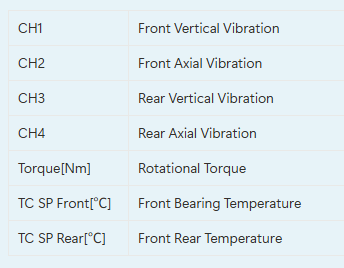

# 데이트 프레임 출력

In [27]:
# 파일 로드
vib_data, operation_data = load_tdms_file(data_dir)
df = create_time_indexed_dataframe(vib_data, operation_data)
df

,CH1,CH2,CH3,CH4,Torque[Nm],TC SP Front[℃],TC SP Rear[℃]
Time (s),,,,,,,
0.000000,0.129623,-0.133638,0.161562,0.231934,-6.781653,110.961,123.6003
0.000039,-0.052214,0.194750,0.134068,0.108986,-6.781653,110.961,123.6003
0.000078,-0.221567,0.074949,-0.348892,0.050421,-6.781653,110.961,123.6003
0.000117,-0.340776,0.062084,-0.429640,-0.023460,-6.781653,110.961,123.6003
0.000156,-0.162668,0.066957,-0.557232,-0.013304,-6.781653,110.961,123.6003
...,...,...,...,...,...,...,...
9.999805,0.067053,0.105000,0.059557,0.241575,-6.781653,110.961,123.6003
9.999844,0.227842,0.207281,0.486917,0.285358,-6.781653,110.961,123.6003
9.999883,0.014009,0.386810,0.180969,0.342836,-6.781653,110.961,123.6003


# Raw 데이터 시각화

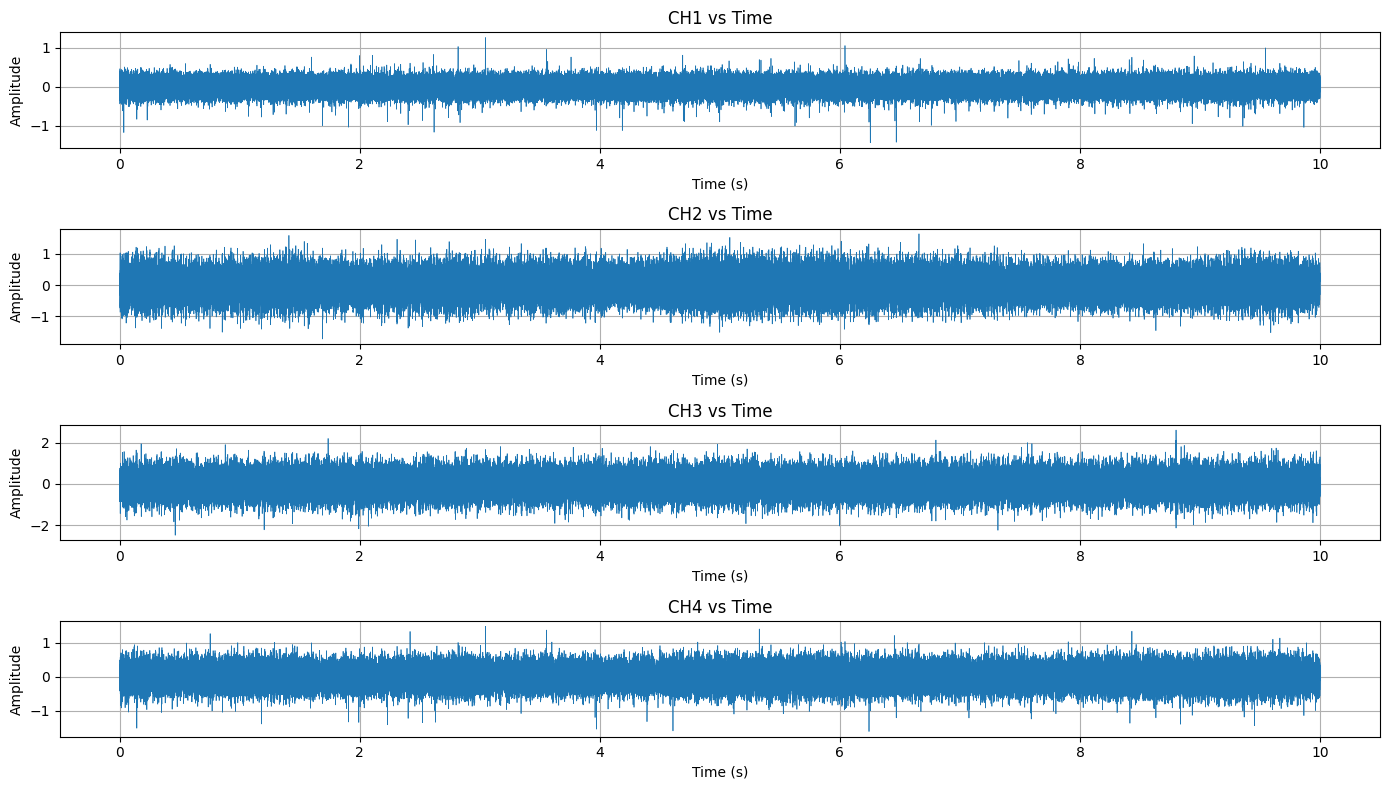

In [26]:
plot_vibration_channels(df)

# RMS 처리 후 시각화(window size = 1000)

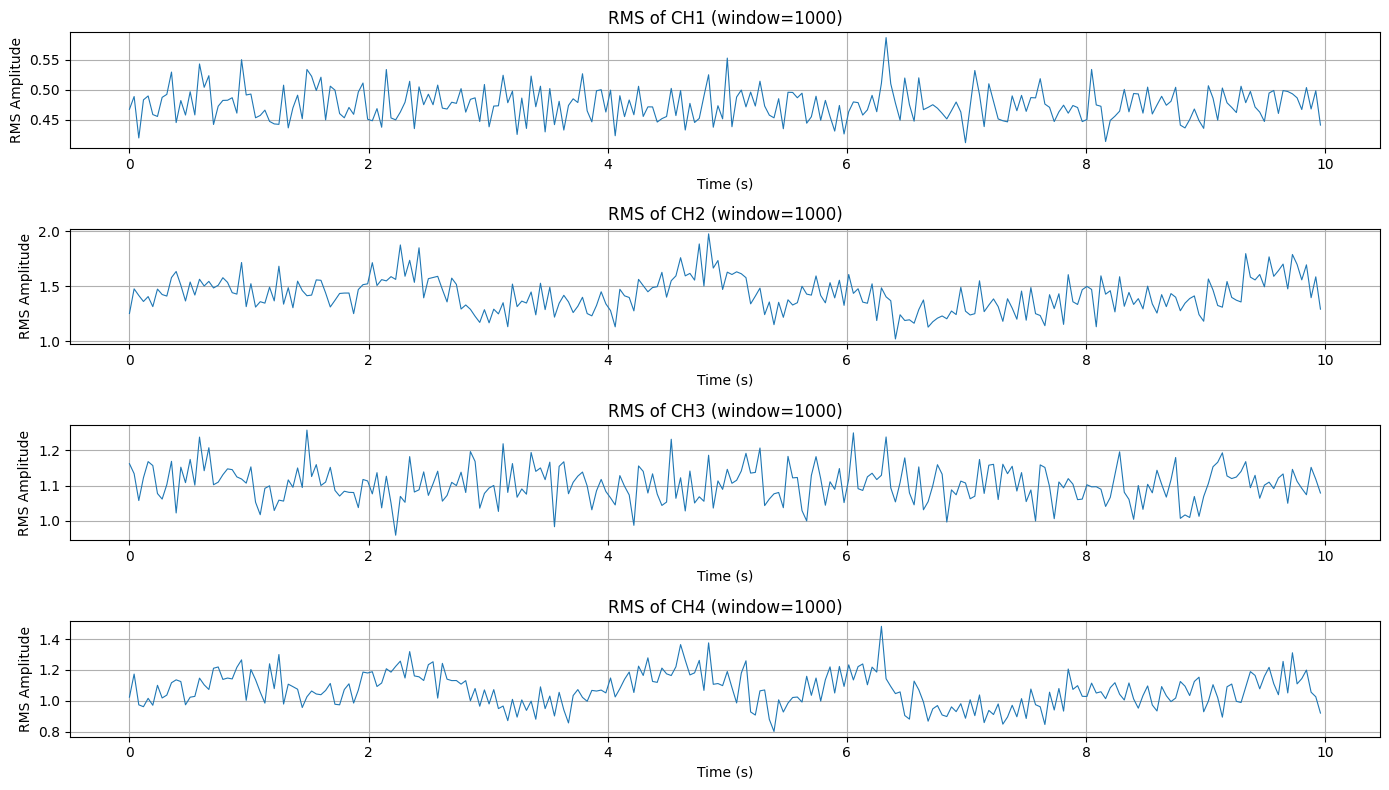

In [20]:
plot_rms_over_time(df)